Roberto Jhoshua Alegre Ventura

# Proyecto: Regresión Bayesiana Gamma para Variables Positivas

## Objetivo general

El objetivo de este proyecto es construir y analizar modelos bayesianos para variables continuas positivas utilizando regresión Gamma.

Los estudiantes deberán implementar modelos bayesianos en NumPyro y evaluar su capacidad predictiva utilizando técnicas de validación cruzada e inferencia posterior.

El proyecto busca integrar:

- modelos lineales generalizados,
- inferencia bayesiana,
- regularización,
- métodos MCMC,
- y modelación de variables positivas asimétricas.

---

# Notación

- $y_i > 0$ representa la variable respuesta.
- $x_i$ es el vector de covariables.
- $\beta$ representa los coeficientes de regresión.
- $\mu_i$ representa la media condicional.
- $\alpha$ representa el parámetro de forma.
- $\tau$ es el hyperparámetro de regularización.
- $X$ representa la matriz de diseño.
- $n$ es el número de observaciones.
- $p$ es el número de covariables.

---

# 1. Variables continuas positivas

La regresión Gamma se utiliza cuando la variable respuesta:

$$
y_i > 0
$$

es:

- continua,
- estrictamente positiva,
- y frecuentemente asimétrica.

Ejemplos:

- tiempos de espera,
- costos,
- ingresos,
- montos de seguros,
- duración de eventos,
- variables biomédicas positivas.

---

# 2. Distribución Gamma

El modelo asume:

$$
y_i
\sim
\text{Gamma}(\alpha,\beta_i)
$$

donde:

- $\alpha$ es el parámetro de forma,
- $\beta_i$ es el parámetro de tasa.

La media satisface:

$$
\mathbb{E}[Y_i]
=
\mu_i
$$

---

# 3. Predictor lineal

La media condicional se modela mediante:

$$
\mu_i
=
\exp(x_i^T\beta)
$$

La función exponencial garantiza:

$$
\mu_i > 0
$$

---

# 4. Link logarítmico

Equivalentemente:

$$
\log(\mu_i)
=
x_i^T\beta
$$

Esto convierte el modelo en un modelo lineal sobre la escala logarítmica.

---

# 5. Priors Bayesianos

Los coeficientes utilizan priors Gaussianos:

$$
\beta_j
\sim
\mathcal{N}(0,\tau^2)
$$

con:

$$
\tau
\sim
\text{HalfNormal}(1)
$$

Esto induce regularización sobre los coeficientes y ayuda a controlar sobreajuste.

---

# 6. Parámetro de forma

El modelo incluye:

$$
\alpha
\sim
\text{HalfNormal}(1)
$$

El parámetro $\alpha$ controla:

- dispersión,
- asimetría,
- variabilidad de la distribución Gamma.

Interpretación general:

- $\alpha$ pequeño:
  - mayor dispersión,
  - mayor asimetría.

- $\alpha$ grande:
  - distribución más concentrada,
  - comportamiento más cercano a Normal.

---

# 7. Inferencia Bayesiana

El objetivo es aproximar la distribución posterior:

$$
p(\beta,\tau,\alpha \mid X,y)
$$

utilizando:

- Markov Chain Monte Carlo (MCMC),
- Hamiltonian Monte Carlo (HMC),
- No-U-Turn Sampler (NUTS).

El resultado final consiste en muestras posteriores de los parámetros y distribuciones predictivas.

---

# 8. Validación Cruzada

La comparación y evaluación del modelo se realizará mediante validación cruzada.

En cada fold:

1. se ajusta el modelo,
2. se generan muestras posteriores,
3. se evalúa desempeño fuera de muestra.

---

# 9. Métrica de evaluación

La métrica principal será el Negative Log-Likelihood (NLL):

$$
\text{NLL}
=
-\log p(y_{\text{valid}} \mid X_{\text{valid}})
$$

Interpretación:

- menor NLL:
  - mejor desempeño predictivo,
  - mejor calibración probabilística.

- mayor NLL:
  - peor capacidad predictiva.

---

# 10. Visualización y análisis posterior

Los estudiantes deberán analizar:

- distribuciones posteriores de coeficientes,
- incertidumbre posterior,
- comportamiento del parámetro $\alpha$,
- estabilidad de parámetros,
- ajuste predictivo,
- interpretación de efectos.

También deberán visualizar:

- densidades posteriores,
- distribuciones predictivas,
- comparación entre observaciones y predicciones.

---

# 11. Objetivos específicos del proyecto

Los estudiantes deberán:

1. Seleccionar un dataset real con respuesta positiva continua.
2. Realizar limpieza y preprocesamiento.
3. Implementar regresión Gamma bayesiana.
4. Ajustar el modelo mediante NUTS.
5. Analizar convergencia MCMC.
6. Evaluar desempeño predictivo.
7. Interpretar coeficientes y parámetros.
8. Analizar incertidumbre posterior.
9. Elaborar conclusiones estadísticas y predictivas.

---

# 12. Entregables sugeridos

El proyecto deberá incluir:

- notebook reproducible,
- explicación teórica,
- análisis exploratorio,
- implementación del modelo,
- métricas de evaluación,
- visualizaciones posteriores,
- interpretación estadística,
- conclusiones.

In [ ]:
import jax
import jax.numpy as jnp
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS, log_likelihood
import jax.random as random
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split, ParameterSampler, KFold
from scipy.stats import distributions as scdist
import numpyro
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
from tqdm import tqdm

numpyro.set_host_device_count(3)
plt.style.use("tableau-colorblind10")

# **Conjunto de datos**

In [13]:
n = 5000
p = 10
alpha = 2.5
seed = 12346
np.random.seed(seed)
X = np.random.rand(n, p)
X = np.hstack((np.ones((n, 1)), X))
beta = 0.5*np.random.rand(p+1)
mu = jnp.exp(X @ beta)
y = dist.Gamma(alpha, alpha/mu).sample(random.PRNGKey(seed))
X = jnp.array(X)
y = jnp.array(y)


X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=18081997)

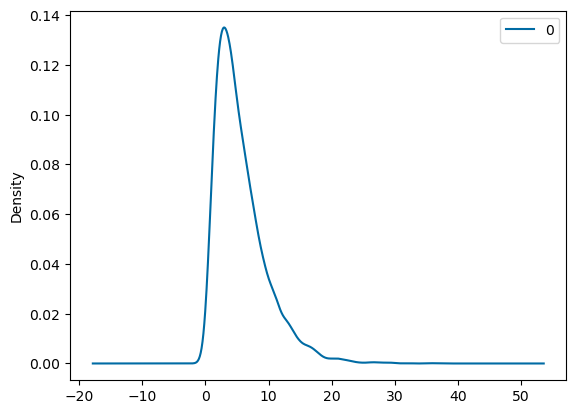

In [14]:
pd.DataFrame(y).plot.kde()
plt.show()

In [21]:
def gamma_regression(X, y=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(1.0))

    beta = numpyro.sample(
            "beta",
            dist.Normal(0, tau).expand([p]).to_event(1)
        )

    alpha = numpyro.sample(
            "alpha",
            dist.HalfNormal(1.0)

        )


    mu = jnp.exp(jnp.matmul(X, beta))

    with numpyro.plate("data", n):

        numpyro.sample(
                "y",
                dist.Gamma(alpha, alpha/mu),
                obs=y
            )

In [22]:
burn_in = 1500
num_samples = 2000
num_chains = 3
chain_method = "parallel"

seed = 18081997

In [23]:
def cv_nll_model(model, X, y, folds=10, seed=1):

    kf = KFold(n_splits=folds, shuffle=True, random_state=seed)

    fold_nll = []

    progress_bar = tqdm(total=folds, desc="Cross Validation")

    for fold, (train_indx, valid_indx) in enumerate(kf.split(X)):

        X_train, X_valid = X[train_indx], X[valid_indx]
        y_train, y_valid = y[train_indx], y[valid_indx]

        rng_key = random.PRNGKey(seed + fold)

        kernel = NUTS(model)

        mcmc = MCMC(kernel,
                        num_samples=num_samples,
                        num_chains=num_chains,
                        num_warmup=burn_in,
                        chain_method=chain_method,
                        progress_bar=False)

        mcmc.run(rng_key, X_train, y_train)

        posterior_samples = mcmc.get_samples()

        nll = -log_likelihood(model, posterior_samples, X_valid, y_valid)["y"].mean(axis=1).mean().item()

        fold_nll.append(nll)

        progress_bar.update(1)
        progress_bar.set_postfix({
            "fold": fold,
            "nll": f"{nll:.4f}"
            })


    progress_bar.close()

    return fold_nll

In [24]:
results_nll = cv_nll_model(gamma_regression, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [01:17<00:00,  7.70s/it, fold=9, nll=2.5319]


In [26]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 2.4973626136779785
std nll: 0.05382416566997606


In [25]:
def linear_regression(X, y=None):

    n, p = X.shape

    tau = numpyro.sample("tau", dist.HalfNormal(1.0))

    Beta = numpyro.sample("beta", dist.Normal(0., tau).expand([p]).to_event(1))
    sigma = numpyro.sample("sigma", dist.HalfNormal(10.))

    mu = jnp.matmul(X, Beta)

    with numpyro.plate("data", n):

        numpyro.sample("y", dist.Normal(mu, sigma), obs=y)

In [27]:
results_nll = cv_nll_model(linear_regression, X_train, y_train)

Cross Validation: 100%|██████████| 10/10 [00:54<00:00,  5.46s/it, fold=9, nll=2.7479]


In [28]:
print("mean nll:", np.mean(results_nll))
print("std nll:", np.std(results_nll))

mean nll: 2.7155746698379515
std nll: 0.05401258675025122


# **Mejor modelo**

In [29]:
rng_key = random.PRNGKey(seed)

kernel = NUTS(gamma_regression)

mcmc = MCMC(kernel,
            num_samples=num_samples,
            num_chains=num_chains,
            num_warmup=burn_in,
            chain_method=chain_method,
            progress_bar=True)

mcmc.run(rng_key, X_train, y_train)

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

  0%|          | 0/3500 [00:00<?, ?it/s]

In [30]:
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
     alpha      2.56      0.05      2.56      2.47      2.64  10112.96      1.00
   beta[0]      0.23      0.05      0.23      0.15      0.32   5384.89      1.00
   beta[1]      0.37      0.03      0.37      0.32      0.42   9825.54      1.00
   beta[2]      0.34      0.03      0.34      0.28      0.39   9091.62      1.00
   beta[3]      0.31      0.03      0.31      0.26      0.36   9876.60      1.00
   beta[4]      0.42      0.03      0.42      0.37      0.48  10013.52      1.00
   beta[5]      0.09      0.03      0.09      0.03      0.14  10265.12      1.00
   beta[6]      0.45      0.03      0.45      0.40      0.51   9430.30      1.00
   beta[7]      0.21      0.03      0.21      0.16      0.27  11432.08      1.00
   beta[8]      0.46      0.03      0.46      0.41      0.52  10987.50      1.00
   beta[9]      0.04      0.03      0.04     -0.02      0.09   9640.05      1.00
  beta[10]      0.23      0

In [31]:
samples = mcmc.get_samples()

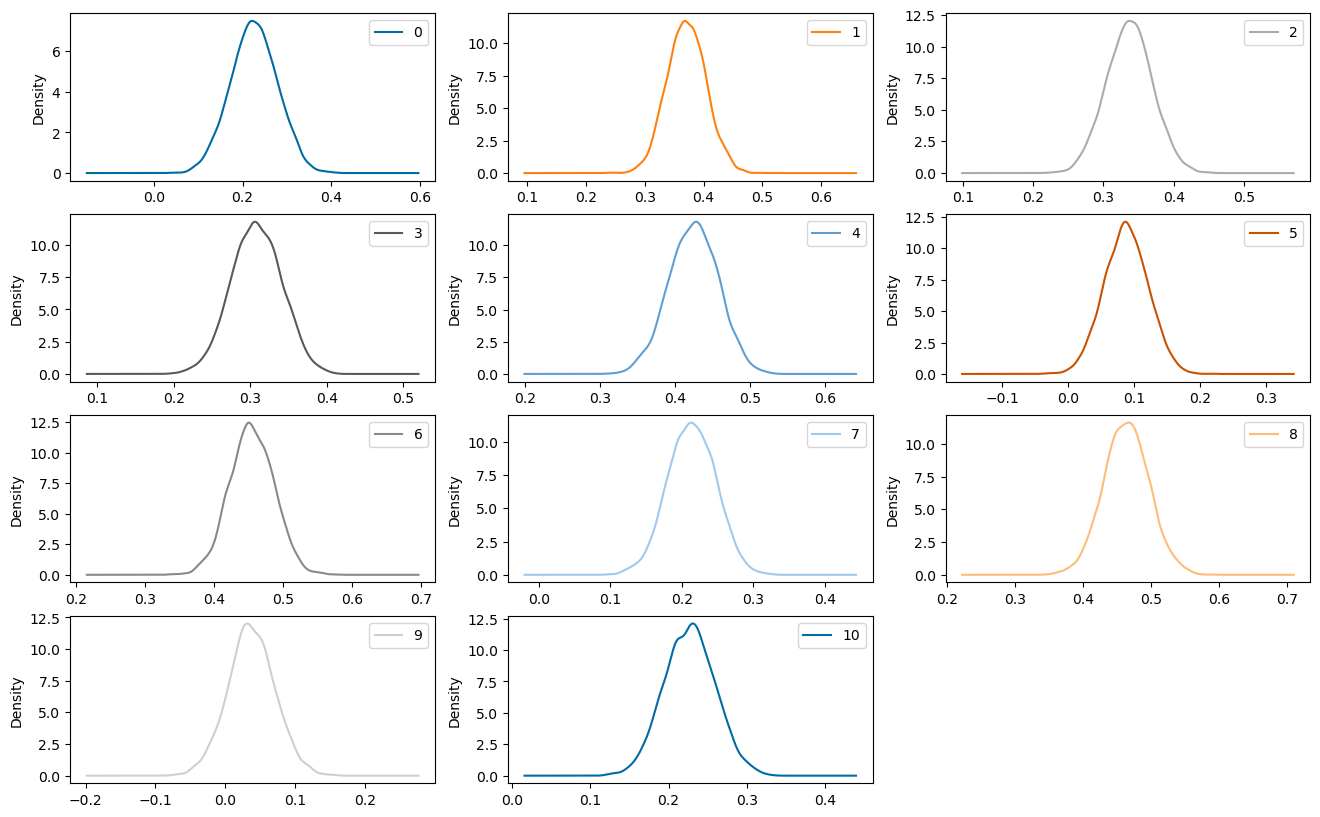

In [32]:
pd.DataFrame(samples["beta"]).plot.kde(subplots=True, layout=(4, 3), sharex=False, figsize=(16, 10))
plt.show()

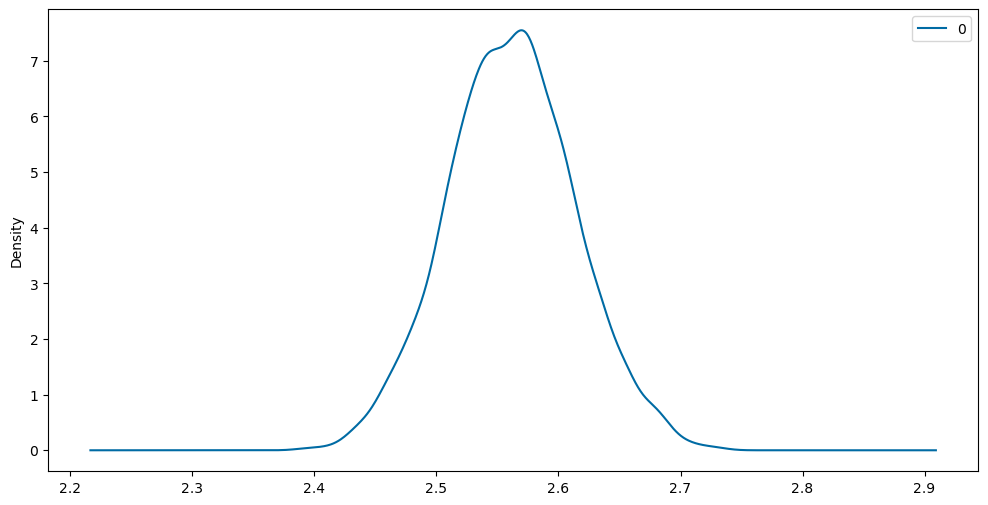

In [34]:
pd.DataFrame(samples["alpha"]).plot.kde(figsize=(12, 6))
plt.show()

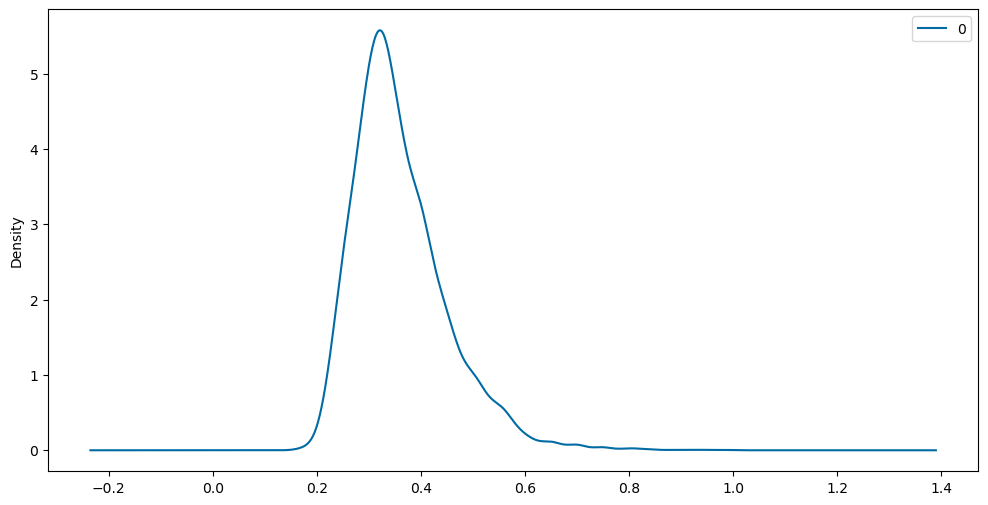

In [35]:
pd.DataFrame(samples["tau"]).plot.kde(figsize=(12, 6))
plt.show()

In [36]:
y_pred_samples = jnp.exp(jnp.matmul(samples["beta"], X_val.T))

y_mean = jnp.mean(y_pred_samples, axis=0)
y_low = jnp.percentile(y_pred_samples, 2.5, axis=0)
y_high = jnp.percentile(y_pred_samples, 97.5, axis=0)

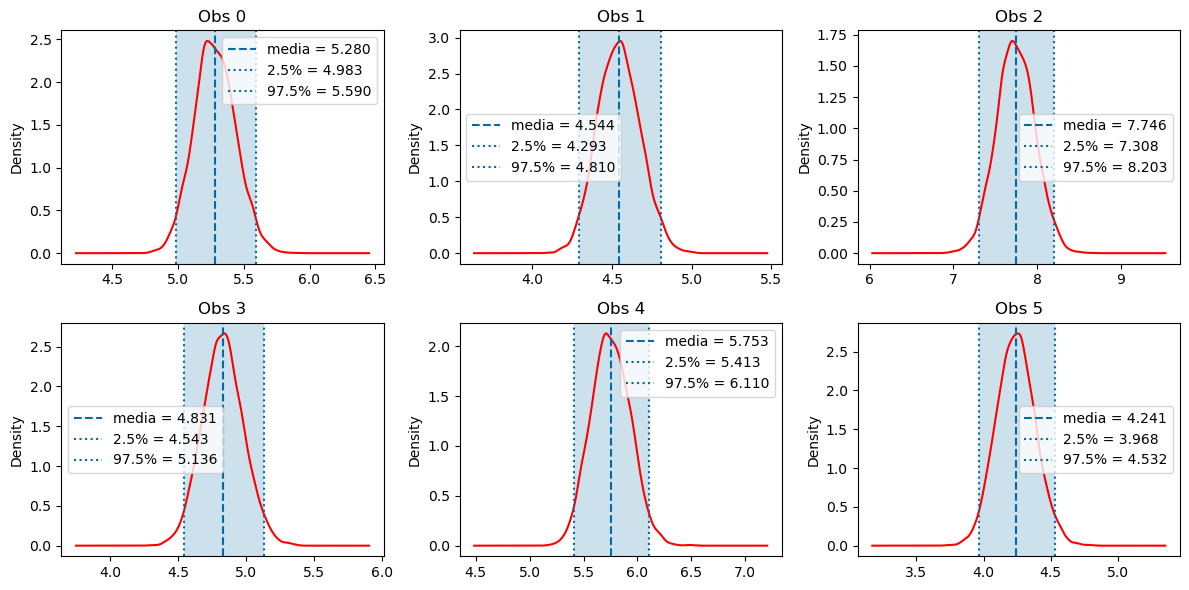

In [38]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6))

axes = axes.flatten()

for i, ax in enumerate(axes):

    # KDE
    pd.Series(np.array(y_pred_samples[:, i])).plot.kde(ax=ax, color="red")

    # media
    ax.axvline(
        y_mean[i],
        linestyle="--",
        label=f"media = {y_mean[i]:.3f}"
    )

    # intervalos
    ax.axvline(
        y_low[i],
        linestyle=":",
        label=f"2.5% = {y_low[i]:.3f}"
    )

    ax.axvline(
        y_high[i],
        linestyle=":",
        label=f"97.5% = {y_high[i]:.3f}"
    )


    ax.axvspan(y_low[i], y_high[i], alpha=0.2)

    ax.set_title(f"Obs {i}")

    ax.legend()

plt.tight_layout()
plt.show()